In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

a) 
Para una matriz A de m x 64, por el teorema de rango y nulidad se cumple que:
rango(A) + dim(Nul(A)) = 64
Para que la imagen pueda reconstruirse de manera única, el rango de A tiene que ser 64. Por lo tanto:
dim(Nul(A)) = 0
Si el rango de A es 64, quiere decir que todas sus columnas son linealmente independientes y que la única solución de Av = 0 es la solución trivial v = 0.
En cambio, si existe un vector no nulo v tal que Av = 0, entonces:
rango(A) < 64 y dim(Nul(A)) > 0
En ese caso, si x es una solución de Ax = b, también x + γv produce las mismas mediciones para cualquier valor de γ, por lo que la reconstrucción no es única.

In [13]:
#b) Construir las matrices A2, A4 y A7 utilizando D2 = {(1, 0),(0, 1)}; 
#D4 = D2 ∪ {(1, 1),(1, −1)}; y D7 = D4 ∪ {(2, 1),(1, 2),(3, 1)}. 
#Para cada matriz, informar sus dimensiones, su rango, la dimensión de su espacio nulo 
#y si permite determinar una imagen de manera única. Comparar la
#cantidad de filas con el rango e identificar la presencia de mediciones redundantes.

def mascara_rayo(n, direccion, s):
    res =  np.zeros((n, n))
    for i in range(n) :
        for j in range(n):
            if (direccion[0]*i + direccion[1]*j) == s:
                res[i,j] =1
    return res
            

def matriz_proyeccion(n, direcciones):
    filas_A = []
    for direccion in direcciones:
        valoresdes=[]
        for i in range(n):
            for j in range(n):
                s = direccion[0]*i + direccion[1]*j
                valoresdes.append(s)
    
        ssinrepetir = []

        for k in valoresdes:
            if k not in ssinrepetir:
                ssinrepetir.append(k)        

        ssinrepetir.sort()

        for s in ssinrepetir:
            fila_s =mascara_rayo(n, direccion, s)
            filas_A.append(fila_s.reshape(-1))
           
    A=np.array(filas_A)
    return A

d2 = [(1,0), (0,1)]
d4 = [(1,0), (0,1), (1,1), (1, -1)]
d7 = [(1,0), (0,1), (1,1), (1, -1), (2,1),(1,2),(3,1)]


A2 = matriz_proyeccion(8, d2)
A4 = matriz_proyeccion(8, d4)
A7= matriz_proyeccion(8, d7)


info_A2 = {"nombre": "A2", "matriz": A2, "dimensiones": A2.shape, "rango": np.linalg.matrix_rank(A2), "dim_nula": A2.shape[1] - rangoA2}
info_A4 = {"nombre": "A4", "matriz": A4, "dimensiones": A4.shape, "rango": np.linalg.matrix_rank(A4), "dim_nula": A4.shape[1] - rangoA4}
info_A7 = {"nombre": "A7", "matriz": A7, "dimensiones": A7.shape, "rango": np.linalg.matrix_rank(A7), "dim_nula": A7.shape[1] - rangoA7}



def analizar(info):
    filas = info["dimensiones"][0]
    columnas = info["dimensiones"][1]
    rango = info["rango"]
    
    print(f"--- {info['nombre']} ---")
    print(f"Dimensiones: {info['dimensiones']}")
    print(f"Rango: {rango}")
    print(f"Dim. espacio nulo: {info['dim_nula']}")
    
    if rango < filas:
        print("Hay mediciones redundantes")
    else:
        print("No hay mediciones redundantes")
    
    if rango == columnas:
        print("Permite reconstrucción única")
    else:
        print("No permite reconstrucción única")
    return 

analizar(info_A2)
analizar(info_A4)
analizar(info_A7)

--- A2 ---
Dimensiones: (16, 64)
Rango: 15
Dim. espacio nulo: 49
Hay mediciones redundantes
No permite reconstrucción única
--- A4 ---
Dimensiones: (46, 64)
Rango: 39
Dim. espacio nulo: 25
Hay mediciones redundantes
No permite reconstrucción única
--- A7 ---
Dimensiones: (119, 64)
Rango: 64
Dim. espacio nulo: 0
Hay mediciones redundantes
Permite reconstrucción única


1.2803073265090195e-15
6.057878560019256e-15


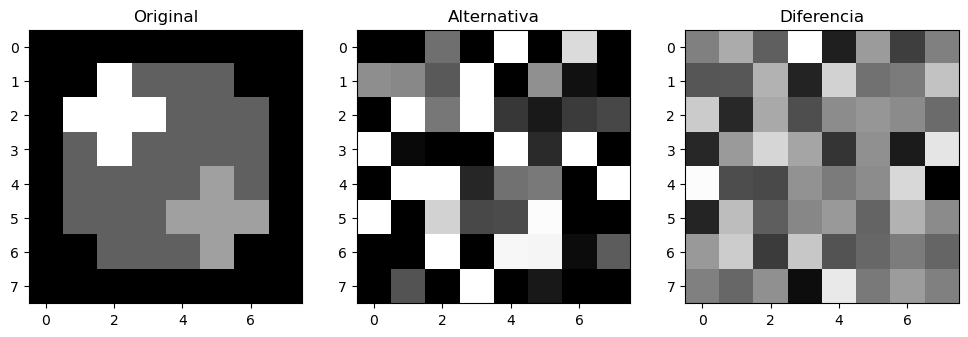

In [ ]:
#c)
X_fantoma = np.array([
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

x_fantoma = X_fantoma.reshape(-1)

U, S, Vt = np.linalg.svd(A4)
v = Vt[-1]
print(np.linalg.norm(A4 @ v))
#si me da cerca de 0 es que v pertenece al espacion nulo de A4 sin ser la solucion trivial

b4 = A4 @ x_fantoma
gamma = 5
x_alt = x_fantoma + gamma * v

b4_alt = A4 @ x_alt
print(np.linalg.norm(b4 - b4_alt))

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(x_fantoma.reshape(8,8), cmap='gray', vmin=x_fantoma.min(), vmax=x_fantoma.max())
axes[0].set_title("Original") #X_fantoma original
axes[1].imshow(x_alt.reshape(8,8), cmap='gray', vmin=x_fantoma.min(), vmax=x_fantoma.max())
axes[1].set_title("Alternativa")#X_fantoma mas el ruido creado por un gamma multiplicado por v
axes[2].imshow((x_fantoma - x_alt).reshape(8,8), cmap='gray')
axes[2].set_title("Ruido") #Solo el ruido 
plt.show()

c) La información invisible para A4 corresponde a las componentes de la imagen que están en su espacio nulo. Esos cambios pueden modificar la imagen píxel a píxel, pero no producen cambios apreciables en las mediciones, ya que A4v ≈ 0. Esto ocurre porque A4 solo mide sumas acumuladas de píxeles a lo largo de un número limitado de direcciones (4 en este caso), D4,  al no cubrir todas las orientaciones posibles, existen patrones en la imagen que distintas combinaciones de píxeles pueden compensar entre sí sin alterar esas sumas.